# Sesion 1: De modelo estatico a servicio con FastAPI

Hasta ahora, cada modelo que entrenamos vivio dentro de un notebook: lo entrenabamos, lo evaluabamos, y ahi se quedaba. En la vida real, un modelo solo genera valor cuando **otra aplicacion puede usarlo**: un sitio web, una app movil, o un sistema interno de la empresa.

Esa conexion se hace a traves de una **API** (Application Programming Interface). En esta sesion vamos a:

1. Entrenar un modelo simple (nuestro caso de negocio: scoring crediticio).
2. Guardarlo en disco con `joblib` para no tener que reentrenarlo cada vez.
3. Construir una API con **FastAPI** que reciba datos de un cliente y devuelva una decision.
4. Probar la API **desde el mismo notebook**, sin necesidad de levantar un servidor real.

Este ultimo punto es importante: Google Colab no esta pensado para correr servidores web expuestos, asi que usaremos una herramienta llamada `TestClient` que simula peticiones HTTP sin salir del notebook. En la Sesion 2 y 3 vamos a preparar todo para que esta misma API corra dentro de un contenedor Docker en una computadora real.

## Paso 1: Entrenar el modelo que vamos a servir

El foco de hoy no es el modelo en si (eso ya lo vimos en modulos anteriores), sino como **servirlo**. Por eso vamos a entrenar algo simple y rapido: un modelo de regresion logistica que decide si se aprueba o no un credito, en base a tres variables: `ingresos`, `edad` y `historial_deuda` (0 = no tiene deuda previa, 1 = si tiene).

Generamos datos sinteticos para no depender de ningun archivo externo.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## generamos un dataset simulado

np.random.seed(42)
n = 500

ingresos = np.random.uniform(300, 5000, n)
edad = np.random.randint(18, 70, n)
historial_deuda = np.random.randint(0, 2, n)

# Regla simulada: mayores ingresos y no tener deuda previa aumentan la probabilidad de aprobacion
score = (ingresos * 0.0006) - (historial_deuda * 1.5) + (edad * 0.01) + np.random.normal(0, 0.5, n)
aprobado = (score > score.mean()).astype(int)

df = pd.DataFrame({
    "ingresos": ingresos,
    "edad": edad,
    "historial_deuda": historial_deuda,
    "aprobado": aprobado
})

df.head()

,ingresos,edad,historial_deuda,aprobado
0,2060.338559,34,1,0
1,4768.357240,26,0,1
2,3740.371527,50,0,1
3,3113.694876,37,1,0
4,1033.287610,30,1,0


In [ ]:
# Entrenamos un modelo para predecir una variable binaria (Logistic Regression)

X = df[["ingresos", "edad", "historial_deuda"]]  # Seleccionamos las variables independientes que usará el modelo
y = df["aprobado"]  # Seleccionamos la variable objetivo que queremos predecir

X_train, X_test, y_train, y_test = train_test_split(  # Dividimos los datos en conjuntos de entrenamiento y prueba
    X, y, test_size=0.2, random_state=42  # Usamos 80% para entrenar y 20% para evaluar; random_state hace la división reproducible
)

modelo = LogisticRegression()  # Creamos el modelo de Logistic Regression
modelo.fit(X_train, y_train)  # Entrenamos el modelo utilizando los datos de entrenamiento

print("Accuracy:", modelo.score(X_test, y_test))  # Calculamos y mostramos la precisión del modelo sobre los datos de prueba

Accuracy: 0.91


In [ ]:
from sklearn.metrics import (f1_score, confusion_matrix)

# Generamos las predicciones sobre los datos de prueba
y_pred = modelo.predict(X_test)

print("F1-score:", round(f1_score(y_test, y_pred),3))

F1-score: 0.903


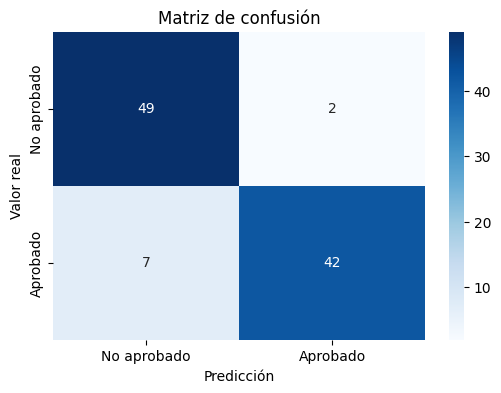

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Mostramos la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No aprobado", "Aprobado"],
    yticklabels=["No aprobado", "Aprobado"],
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

## Paso 2: Serializar el modelo con joblib

Entrenar el modelo puede tomar horas. No queremos reentrenar cada vez que alguien reinicia la API. Por eso **serializamos** el modelo: lo convertimos en un archivo binario que se puede guardar, mover a otra computadora, y volver a cargar tal cual quedo entrenado.

La libreria estandar para serializar con scikit-learn es `joblib`.

In [ ]:
import joblib

# Guardar el modelo entrenado en un archivo binario (.pkl)
joblib.dump(modelo, "model.pkl")

# Cargar el modelo desde el archivo para verificar la persistencia
modelo_cargado = joblib.load("model.pkl")

# Probar que el modelo cargado realiza predicciones correctamente con un subconjunto de prueba
print(modelo_cargado.predict(X_test.iloc[:3]))

[1 0 0]


>Que es el formato `.pkl` ?
>
>El formato **`.pkl` (Pickle)** permite guardar objetos de Python en un archivo binario para poder **reutilizarlos posteriormente** sin tener que crearlos o entrenarlos nuevamente.
>
>En Machine Learning, podemos guardar un modelo entrenado y luego cargarlo para realizar nuevas predicciones.

### ----- Recordatorio: *clases* en Python -----

Una clase funciona como una plantilla (template) para crear objetos.

Con `__init__` definimos qué datos recibe el objeto cuando lo creamos.
Con `self` guardamos esos datos como atributos del objeto.

Ejemplo: cada objeto `Cliente` tendrá tres atributos:
`ingresos`, `edad` e `historial_deuda`.

In [ ]:
class Cliente:
    def __init__(self, ingresos, edad, historial_deuda):  # Inicializamos el objeto con los datos del cliente
        self.ingresos = ingresos  # Guardamos los ingresos como atributo del objeto
        self.edad = edad  # Guardamos la edad como atributo del objeto
        self.historial_deuda = historial_deuda  # Guardamos el historial de deuda como atributo del objeto


# Creamos un objeto de la clase Cliente
cliente = Cliente(2500, 35, 0)

print(cliente.ingresos)
print(cliente.edad)
print(cliente.historial_deuda)

2500
35
0


Similarmente, en una API necesitamos definir **qué datos esperamos recibir** de un cliente. En nuestro caso, esperamos datos como `ingresos`, `edad` e `historial_deuda`.


Mas abajo, utilizaremos **Pydantic** para crear una clase similar:

`ClienteInput(BaseModel)`

La diferencia es que Pydantic, además de crear el objeto, **valida que los datos recibidos tengan los tipos y la estructura esperados**.

Después, FastAPI utilizará esta clase en nuestro endpoint `/predict` para recibir y validar los datos antes de enviarlos al modelo de Machine Learning.

En resumen:

**Cliente → API → Pydantic valida los datos → Modelo ML → Predicción → Respuesta**

## Paso 3: Instalar las herramientas para construir la API

Vamos a usar tres librerias:

- **FastAPI**: el framework que define los endpoints (las "rutas" de nuestra API).
- **Pydantic**: viene integrado con FastAPI y se usa para validar que los datos que llegan tengan el tipo correcto (por ejemplo, que `edad` sea un numero y no un texto).
- **uvicorn**: el servidor que efectivamente ejecuta la API. Lo vamos a necesitar mas adelante, cuando corramos todo dentro de Docker.

In [ ]:
!pip install -q fastapi uvicorn pydantic

## Paso 4: Escribir el archivo main.py

Una API necesita vivir en un **archivo .py independiente**, porque va a ser ese archivo el que se ejecute en el servidor (o dentro del contenedor Docker).

Usamos `%%writefile` escribir el contenido de una celda directamente a un archivo, en vez de ejecutarlo.

Nuestra API va a tener:

- Un endpoint `GET /health`, que sirve para verificar rapidamente que la API esta corriendo.
- Un endpoint `POST /predict`, que recibe los datos de un cliente en formato JSON y devuelve la decision del modelo.
- Una clase `ClienteInput` basada en Pydantic, que define y valida la forma que deben tener los datos de entrada.

In [ ]:
# Creamos el archivo main.py con el código de nuestra API
%%writefile main.py

import joblib  # joblib para cargar el modelo entrenado
from fastapi import FastAPI  # FastAPI para crear la API
from pydantic import BaseModel  # Pydantic BaseModel para validar los datos recibidos

# Creamos la aplicación FastAPI con un título descriptivo
app = FastAPI(title="API de Scoring Crediticio")

# Cargamos el modelo entrenado desde el archivo model.pkl
modelo = joblib.load("model.pkl")


# Definimos la estructura de datos que la API espera recibir
class ClienteInput(BaseModel):
    ingresos: float  # Los ingresos deben ser un número decimal
    edad: int  # La edad debe ser un número entero
    historial_deuda: int  # 0: no tiene deuda previa, 1: sí tiene


# Creamos un endpoint GET para comprobar que la API está funcionando
@app.get("/health")
def health():  # Definimos la función que responde a la solicitud de health
    return {"status": "online"}  # Devolvemos el estado actual de la API

# Creamos un endpoint POST para realizar predicciones
@app.post("/predict")
def predict(cliente: ClienteInput):  # Recibimos los datos del cliente validados por Pydantic (usando ClienteInput())
    datos = [[cliente.ingresos, cliente.edad, cliente.historial_deuda]]  # Organizamos los datos en el formato que espera el modelo
    prediccion = modelo.predict(datos)[0]  # Usamos el modelo para generar la predicción
    decision = "Aprobado" if prediccion == 1 else "Rechazado"  # Convertimos la predicción numérica en una decisión legible

    return {  # Devolvemos la información de la predicción en formato JSON (como dictionario)
        "edad": cliente.edad,  # Incluimos la edad recibida
        "decision": decision  # Incluimos la decisión generada por el modelo
    }

Writing main.py


### ----- Recordatorio: decorators en Python -----

Un **decorator** es una función que permite **modificar o agregar comportamiento a otra función** sin cambiar directamente su código.
Se utiliza con el símbolo @ y se coloca justo antes de la función que queremos decorar.

En este contexto, FastAPI utiliza decorators como `@app.get()` y `@app.post()` para **registrar una función como un endpoint de la API** y asociarla con una ruta y un método HTTP.

Por ejemplo:

`@app.get("/health")` indica que la función `health()` se ejecutará cuando la API reciba una solicitud **GET** a `/health`.

`@app.post("/predict")` indica que la función `predict()` se ejecutará cuando la API reciba una solicitud **POST** a `/predict`.

## Paso 5: Probar la API sin salir del notebook

Para probar una API hay que levantar un servidor (`uvicorn main:app`) y hacerle peticiones desde otra ventana. A dentro de Colab, vamos a hacerlo un poco diferente (explicamos como se hace a fuera de Colab despues) .

Para probar la logica de la API sin salir del notebook, usamos `TestClient`: simula peticiones HTTP reales contra nuestra app, sin necesidad de un servidor corriendo. Es una herramienta que tambien se usa en proyectos reales para escribir tests automatizados.

In [ ]:
from main import app  # Importamos la aplicación FastAPI desde main.py
from fastapi.testclient import TestClient  # Importamos TestClient para probar la API sin levantar el servidor

client = TestClient(app)  # Creamos un cliente de prueba que puede enviar solicitudes a nuestra API
# print(dir(client))


In [ ]:
# Probamos el endpoint de salud
respuesta_health = client.get("/health")  # Enviamos una solicitud GET al endpoint /health
print("GET /health ->", respuesta_health.json())  # Mostramos la respuesta de la API en formato JSON

# Probamos el endpoint de predicción con un cliente de ejemplo
cliente_ejemplo = {  # Creamos los datos que enviaremos al endpoint /predict
    "ingresos": 2500.0,  # Definimos los ingresos del cliente
    "edad": 35,  # Definimos la edad del cliente
    "historial_deuda": 0  # Indicamos que el cliente no tiene deuda previa
}

respuesta_predict = client.post("/predict", json=cliente_ejemplo)  # Enviamos los datos mediante una solicitud POST
print("POST /predict ->", respuesta_predict.json())  # Mostramos la respuesta de la API en formato JSON

GET /health -> {'status': 'online'}
POST /predict -> {'edad': 35, 'decision': 'Aprobado'}


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Agregamos un segundo caso de uso a la misma API:

- Un endpoint `POST /proyeccion` que reciba un valor `ventas_mensuales` (float) y devuelva `proyeccion_comision`, calculada como el 10% de las ventas.


1. Tenemos que definir una nueva clase de Pydantic (por ejemplo `VentasInput`) con el campo `ventas_mensuales`.
2. Agregar la funcion con el decorador `@app.post("/proyeccion")`.
3. Vuelver a escribir el archivo `main.py` completo con `%%writefile` (FastAPI necesita el archivo completo, no se puede "agregar" una funcion suelta).
4. Probar el nuevo endpoint con `TestClient`, igual que hicimos arriba.

In [ ]:
# Reescribimos el archivo main.py completo con nuestra API
%%writefile main.py

import joblib  # Importamos joblib para cargar el modelo entrenado
from fastapi import FastAPI  # Importamos FastAPI para crear la API
from pydantic import BaseModel  # Importamos BaseModel para validar los datos recibidos

app = FastAPI(title="API de Scoring Crediticio")  # Creamos la aplicación FastAPI

# Cargamos el modelo una sola vez, cuando arranca la API
modelo = joblib.load("model.pkl")  # Cargamos el modelo entrenado desde el archivo model.pkl


class ClienteInput(BaseModel):  # Definimos la estructura de datos para el endpoint /predict
    ingresos: float  # Los ingresos deben ser un número decimal
    edad: int  # La edad debe ser un número entero
    historial_deuda: int  # 0: no tiene deuda previa, 1: sí tiene

# -------------------------------- nueva clase :

class VentasInput(BaseModel):  # Definimos la estructura de datos para el endpoint /proyeccion
    ventas_mensuales: float  # Las ventas mensuales deben ser un número decimal


@app.get("/health")  # Creamos un endpoint GET para comprobar que la API está funcionando
def health():  # Definimos la función que responde a la solicitud
    return {"status": "online"}  # Devolvemos el estado de la API


@app.post("/predict")  # Creamos un endpoint POST para realizar predicciones
def predict(cliente: ClienteInput):  # Recibimos los datos del cliente validados por Pydantic
    datos = [[cliente.ingresos, cliente.edad, cliente.historial_deuda]]  # Organizamos los datos para el modelo
    prediccion = modelo.predict(datos)[0]  # Generamos la predicción con el modelo
    decision = "Aprobado" if prediccion == 1 else "Rechazado"  # Convertimos la predicción en una decisión

    return {  # Devolvemos la respuesta en formato JSON
        "edad": cliente.edad,  # Incluimos la edad del cliente
        "decision": decision  # Incluimos la decisión generada por el modelo
    }


# -------------------------------- nuevo codigo :

@app.post("/proyeccion")  # Creamos un endpoint POST para calcular la proyección de comisión
def proyeccion(ventas: VentasInput):  # Recibimos las ventas mensuales validadas por Pydantic
    comision = ventas.ventas_mensuales * 0.10  # Calculamos la comisión como el 10% de las ventas

    return {  # Devolvemos la respuesta en formato JSON
        "proyeccion_comision": comision  # Incluimos el valor calculado de la comisión
    }

Overwriting main.py


Hacemos la prueba

In [ ]:
import importlib
import main

importlib.reload(main)  # Recargamos main.py para incorporar el nuevo endpoint

from fastapi.testclient import TestClient

client = TestClient(main.app)  # Usamos la aplicación actualizada de main.py

ventas_ejemplo = {
    "ventas_mensuales": 5000.0  # Definimos las ventas mensuales de ejemplo
}

respuesta_proyeccion = client.post(
    "/proyeccion",  # Indicamos el endpoint al que enviaremos los datos
    json=ventas_ejemplo  # Enviamos los datos en formato JSON
)

print("POST /proyeccion ->", respuesta_proyeccion.json())  # Mostramos la respuesta

POST /proyeccion -> {'proyeccion_comision': 500.0}


---
## Paso 6: Probar la API a fuera del notebook

## Crear y ejecutar una API con FastAPI

### 1. Crear la carpeta del proyecto

Crear una carpeta llamada **`credit_scoring_api`** en el computador.

La estructura final será:

```text
credit_scoring_api/
│
├── main.py
├── model.pkl
└── .venv/

###2. Abrir la carpeta en VS Code
Abrir VS Code y seleccionar:
File → Open Folder... → credit_scoring_api  

Es importante abrir la carpeta completa, no solamente el archivo main.py.  


### 3. Abrir la terminal
En VS Code seleccionar:  

Terminal → New Terminal  

La terminal debe estar ubicada dentro de la carpeta credit_scoring_api.  
Podemos comprobarlo con:  
```pwd```

### 4. Crear un entorno virtual
En macOS:  
```python3 -m venv .venv```
  
En Window:  
```python3 -m venv .venv```

Activar el entorno virtual:  
```source .venv/bin/activate```

Si aparece (.venv) al inicio de la línea de la terminal, el entorno está activo.

### 5. Instalar las librerías
Instalar las dependencias necesarias:  
```
pip install fastapi uvicorn joblib scikit-learn
```

### 6. Copiar el modelo entrenado  
Copiar el archivo model.pkl, generado durante el entrenamiento en Google Colab, dentro de la carpeta credit_scoring_api.  
  
La carpeta debe contener:  
```
credit_scoring_api/
│
├── main.py
├── model.pkl
└── .venv/

```

###7. Crear main.py  

Crear el archivo main.py en VS Code y colocar el código de nuestra API.

El contenido de ```main.py```:
```
import joblib
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="Credit Scoring API")

# Load the trained model once when the API starts
modelo = joblib.load("model.pkl")


class ClienteInput(BaseModel):
    ingresos: float
    edad: int
    historial_deuda: int


class VentasInput(BaseModel):
    ventas_mensuales: float


@app.get("/health")
def health():
    return {"status": "online"}


@app.post("/predict")
def predict(cliente: ClienteInput):
    datos = [[
        cliente.ingresos,
        cliente.edad,
        cliente.historial_deuda
    ]]

    prediccion = modelo.predict(datos)[0]

    decision = "Aprobado" if prediccion == 1 else "Rechazado"

    return {
        "edad": cliente.edad,
        "decision": decision
    }


@app.post("/proyeccion")
def proyeccion(ventas: VentasInput):
    comision = ventas.ventas_mensuales * 0.10

    return {
        "proyeccion_comision": comision
    }

```
  
La API tendrá tres endpoints:  

- GET /health → comprueba que la API está funcionando.
- POST /predict → recibe datos de un cliente y genera una predicción con el modelo.
- POST /proyeccion → recibe las ventas mensuales y calcula una comisión del 10%.

### 8. Ejecutar la API con Uvicorn  

Desde la terminal de VS Code:  
```
uvicorn main:app --reload
```
Uvicorn inicia el servidor y permite recibir solicitudes HTTP.  
Si todo funciona correctamente, veremos:
```
Uvicorn running on http://127.0.0.1:8000
```


### 9. Abrir la documentación interactiva   
Abrir en el navegador:  
```
http://127.0.0.1:8000/docs
```
FastAPI genera automáticamente una interfaz donde podemos probar nuestros endpoints.

---
### Flujo completo  
```
Modelo entrenado en Colab
          ↓
      model.pkl
          ↓
   credit_scoring_api
          ↓
       main.py
          ↓
      FastAPI
          ↓
      Uvicorn
          ↓
      API local
          ↓
http://127.0.0.1:8000/docs
          ↓
    Probar endpoints

**Conceptos principales**  
- FastAPI → crea la API y define los endpoints.
- Pydantic → valida los datos recibidos.
- joblib → carga el modelo entrenado.
- Uvicorn → ejecuta el servidor de la API.
- main.py → contiene el código de nuestra API.
- model.pkl → contiene el modelo entrenado.
- /health → verifica que la API está funcionando.
- /predict → utiliza el modelo para generar predicciones.
- /proyeccion → implementa un segundo caso de uso.
- /docs → permite probar la API de forma interactiva.